In [ ]:
import pandas as pd
import seaborn as sns

df = pd.read_csv('winequality.csv')
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
Q1=df['alcohol'].quantile(0.25)
Q3=df['alcohol'].quantile(0.75)
Q1,Q3

(np.float64(9.5), np.float64(11.3))

Quartile 1 (25%) and Quartile 3 (75%)

In [ ]:
IQR = Q3 - Q1
IQR

np.float64(1.8000000000000007)

Lower Bound and Upper Bound

In [ ]:
lb = Q1 - (0.5 * IQR)
ub = Q3 + (0.5 * IQR)
lb,ub

(np.float64(8.6), np.float64(12.200000000000001))

**Detecting the Outliers**

***Syntax*** :  df['columnName']=[df['columnName'] < lb | df['columnName'] > ub ]

Smaller datasets -----> keep outliers   
Bigger dataset -------> remove outliers

In [ ]:
# df['columnName']=[df['columnName'] < lb | df['columnName'] > ub ]

In [ ]:
outliers = df[(df['alcohol'] < lb) | (df['alcohol'] > ub)]
# df[(df['alcohol'] < 8.6) | (df['alcohol'] > 12.20)]
outliers['alcohol'].unique()



array([12.4       , 12.8       , 12.3       , 12.6       , 12.7       ,
        8.5       , 12.5       , 12.9       , 13.9       , 14.        ,
       13.5       , 13.3       , 13.2       , 13.7       , 13.4       ,
       13.        ,  8.        , 13.1       , 13.6       ,  8.4       ,
       14.2       , 12.89333333, 14.05      , 12.33333333, 12.75      ,
       13.8       , 13.05      , 12.25      , 13.55      , 13.13333333,
       14.9       , 13.56666667])

In [ ]:
out=[]
for i in df['alcohol']:
  if i>ub:
    out.append(ub)
  else:
    out.append(i)
out

[8.8,
 9.5,
 10.1,
 9.9,
 9.9,
 10.1,
 9.6,
 8.8,
 9.5,
 11.0,
 12.0,
 9.7,
 10.8,
 np.float64(12.200000000000001),
 9.7,
 11.4,
 9.6,
 np.float64(12.200000000000001),
 11.3,
 9.5,
 np.float64(12.200000000000001),
 11.0,
 10.5,
 9.3,
 10.0,
 10.4,
 10.0,
 10.5,
 11.6,
 np.float64(12.200000000000001),
 10.0,
 10.2,
 10.8,
 9.0,
 10.2,
 np.float64(12.200000000000001),
 10.0,
 11.2,
 8.6,
 8.6,
 9.4,
 9.4,
 9.8,
 9.5,
 9.5,
 10.0,
 9.8,
 9.8,
 9.8,
 9.8,
 11.7,
 11.0,
 10.9,
 10.9,
 9.1,
 11.0,
 9.6,
 8.9,
 10.2,
 9.9,
 8.6,
 8.9,
 10.5,
 10.2,
 10.3,
 9.1,
 np.float64(12.200000000000001),
 9.8,
 10.7,
 9.5,
 9.0,
 9.5,
 10.0,
 9.1,
 10.7,
 9.5,
 np.float64(12.200000000000001),
 12.0,
 9.3,
 9.0,
 10.6,
 9.2,
 10.0,
 9.5,
 8.7,
 8.7,
 8.7,
 9.7,
 8.7,
 8.7,
 8.7,
 9.0,
 np.float64(12.200000000000001),
 np.float64(12.200000000000001),
 11.5,
 9.2,
 8.8,
 11.4,
 10.1,
 8.8,
 9.1,
 9.4,
 9.4,
 9.0,
 9.1,
 9.2,
 9.4,
 9.1,
 9.1,
 10.3,
 8.8,
 8.9,
 9.2,
 9.1,
 9.1,
 9.7,
 11.3,
 11.8,
 9.2,
 

In [ ]:
df['alcohol'] = out

<Axes: ylabel='alcohol'>

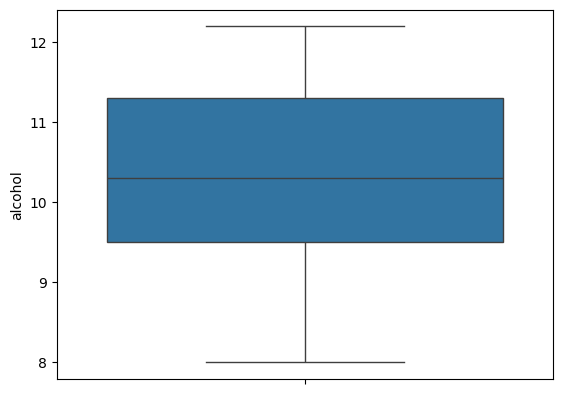

In [ ]:
sns.boxplot(df['alcohol'])

In [ ]:
Q1=df['pH'].quantile(0.25)
Q3=df['pH'].quantile(0.75)
Q1,Q3

IQR = Q3 - Q1
IQR

lb = Q1 - (1.5 * IQR)
ub = Q3 + (1.5 * IQR)
lb,ub

outliers = df[(df['pH'] < lb) | (df['pH'] > ub)]
# df[(df['alcohol'] < 2.795) | (df['alcohol'] > 3.635)]
outliers['pH'].unique()

out=[]
for i in df['pH']:
  if i>ub:
    out.append(ub)
  elif i<lb:
    out.append(lb)
  else:
    out.append(i)
out

df['pH'] = out



<Axes: ylabel='pH'>

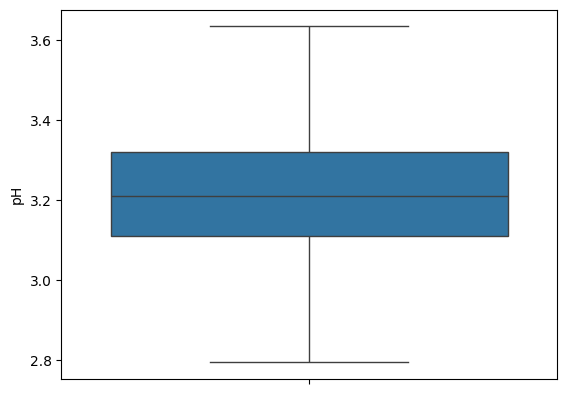

In [ ]:
sns.boxplot(df['pH'])